In [1]:
from src.measure_ir import *

import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from scipy.signal import correlate
from src.real_time import RealtimeFxLMS
import time
import gc

In [2]:
fs = 48000
x = np.zeros((fs,), dtype=np.float32)
x[0] = 1.0

In [3]:
ad = AudioDevice(fs)

In [4]:
error, ref = ad.play(source_out=x, blocking=True)
error_nb, ref_nb = ad.play(source_out=x, blocking=False)
time.sleep(1.1)

In [5]:
corr = correlate(error, x, mode='full')
lags = np.arange(-len(x)+1, len(error))
lag = lags[np.argmax(np.abs(corr))]
lag

np.int64(376)

In [6]:
corr_nb = correlate(error_nb, x, mode='full')
lags_nb = np.arange(-len(x)+1, len(error_nb))
lag_nb = lags_nb[np.argmax(np.abs(corr_nb))]
lag_nb

np.int64(377)

In [7]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')

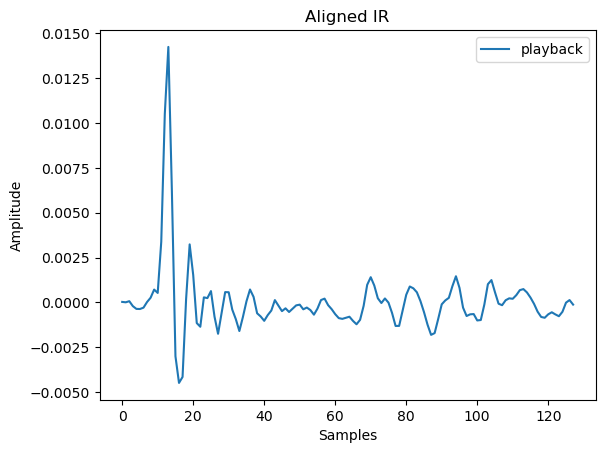

In [8]:
ir_len = 128
panel_to_err_cm = 9

error_ir, _ = measure_ir(ad)
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.legend()
plt.show()

In [9]:
block_sizes = ad.available_buffer_sizes
system_delays = []
full_delays = []
other_delays = []

for block in block_sizes:
    print("block size:", block, "expected_delay_samples:", round(ad.per_buffer_latency_s[block] * ad.fs))
    rt = RealtimeFxLMS(
        ad,
        source=arthur,
        ir=panel_ir,
        block_size=block
    )
    print()
    system_delays.append(rt.system_lag)
    full_delays.append(rt.full_lag)
    other_delays.append(rt.full_lag - rt.system_lag)
    time.sleep(5)
    gc.collect()
    time.sleep(5)

block size: 16 expected_delay_samples: 235
Lag from cross-correlation: 1286
Delay from device: 1112

block size: 32 expected_delay_samples: 264
Lag from cross-correlation: 1477
Delay from device: 1304

block size: 48 expected_delay_samples: 298
Lag from cross-correlation: 1669
Delay from device: 1496

block size: 64 expected_delay_samples: 379
Lag from cross-correlation: 1860
Delay from device: 1688

block size: 96 expected_delay_samples: 442
Lag from cross-correlation: 2250
Delay from device: 2072

block size: 128 expected_delay_samples: 696
Lag from cross-correlation: 3403
Delay from device: 3224

block size: 160 expected_delay_samples: 859
Lag from cross-correlation: 4170
Delay from device: 3992

block size: 192 expected_delay_samples: 922
Lag from cross-correlation: 4170
Delay from device: 3992

block size: 256 expected_delay_samples: 1243
Lag from cross-correlation: 4485
Delay from device: 4312

block size: 512 expected_delay_samples: 2232
Lag from cross-correlation: 4490
Delay fr

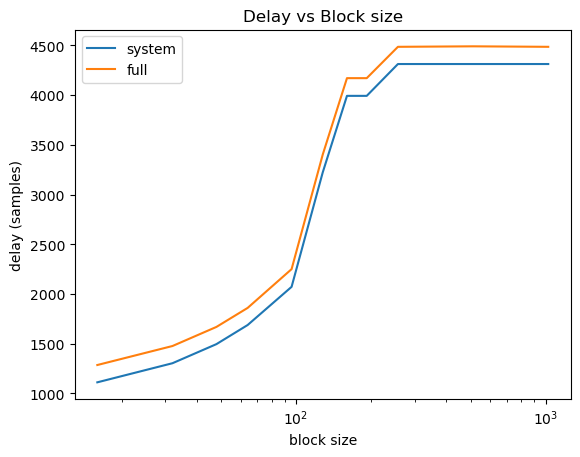

In [10]:
plt.plot(block_sizes, system_delays, label="system")
plt.plot(block_sizes, full_delays, label="full")

plt.title("Delay vs Block size")
plt.xlabel("block size")
plt.ylabel("delay (samples)")
plt.xscale('log')
plt.legend()
plt.show()

In [12]:
block_sizes = ad.available_buffer_sizes
system_delays = []
full_delays = []
other_delays = []

for block in block_sizes:
    print("block size:", block, "expected_delay_samples:", round(ad.per_buffer_latency_s[block] * ad.fs))
    rt = RealtimeFxLMS(
        ad,
        source=arthur,
        ir=panel_ir,
        block_size=block,
        latency=0.0
    )
    print()
    system_delays.append(rt.system_lag)
    full_delays.append(rt.full_lag)
    other_delays.append(rt.full_lag - rt.system_lag)
    time.sleep(5)
    gc.collect()
    time.sleep(5)

block size: 16 expected_delay_samples: 235
Lag from cross-correlation: 406
Delay from device: 232

block size: 32 expected_delay_samples: 264
Lag from cross-correlation: 443
Delay from device: 264

block size: 48 expected_delay_samples: 298
Lag from cross-correlation: 468
Delay from device: 296

block size: 64 expected_delay_samples: 379
Lag from cross-correlation: 554
Delay from device: 376

block size: 96 expected_delay_samples: 442
Lag from cross-correlation: 613
Delay from device: 440

block size: 128 expected_delay_samples: 696
Lag from cross-correlation: 874
Delay from device: 696

block size: 160 expected_delay_samples: 859
Lag from cross-correlation: 1035
Delay from device: 856

block size: 192 expected_delay_samples: 922
Lag from cross-correlation: 1099
Delay from device: 920

block size: 256 expected_delay_samples: 1243
Lag from cross-correlation: 1418
Delay from device: 1240

block size: 512 expected_delay_samples: 2232
Lag from cross-correlation: 2411
Delay from device: 223

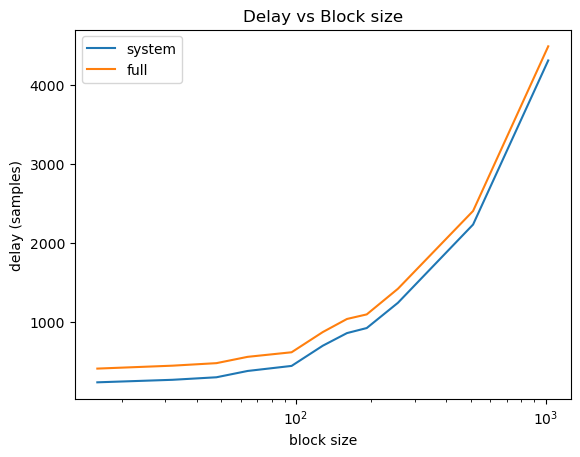

In [ ]:
plt.plot(block_sizes, system_delays, label="system")
plt.plot(block_sizes, full_delays, label="full")

plt.title("Delay vs Block size")
plt.xlabel("block size")
plt.ylabel("delay (samples)")
plt.xscale('log')
plt.legend()
plt.show()